**General Training Pipeline**

*   Design model
*   Construct loss
*   Construct optimizer
*   Training loop:
    1.   Forward pass: Compute prediction
    2.   Backward pass: Compute Gradients
    3.   Weights update

# Linear Regression

Implementation from scratch

Initially, w =  -0.4010
At itertion  100 , w =  7.6502 , b =  1.3233 , loss =  0.5730  prediction =  77.8250  actual =  53.0000
At itertion  200 , w =  6.8610 , b =  1.8543 , loss =  0.2801  prediction =  70.4648  actual =  53.0000
At itertion  300 , w =  6.3108 , b =  2.2246 , loss =  0.1377  prediction =  65.3328  actual =  53.0000
At itertion  400 , w =  5.9272 , b =  2.4827 , loss =  0.0685  prediction =  61.7545  actual =  53.0000
At itertion  500 , w =  5.6597 , b =  2.6627 , loss =  0.0348  prediction =  59.2595  actual =  53.0000
At itertion  600 , w =  5.4732 , b =  2.7883 , loss =  0.0184  prediction =  57.5198  actual =  53.0000
At itertion  700 , w =  5.3431 , b =  2.8758 , loss =  0.0105  prediction =  56.3068  actual =  53.0000
At itertion  800 , w =  5.2524 , b =  2.9368 , loss =  0.0066  prediction =  55.4610  actual =  53.0000
At itertion  900 , w =  5.1892 , b =  2.9793 , loss =  0.0047  prediction =  54.8713  actual =  53.0000
At itertion  1000 , w =  5.1451 , b =  3

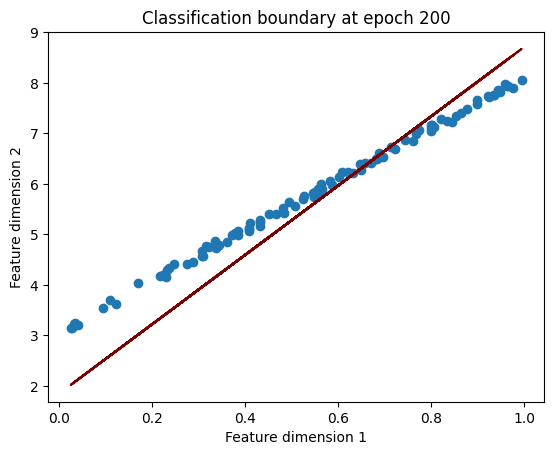

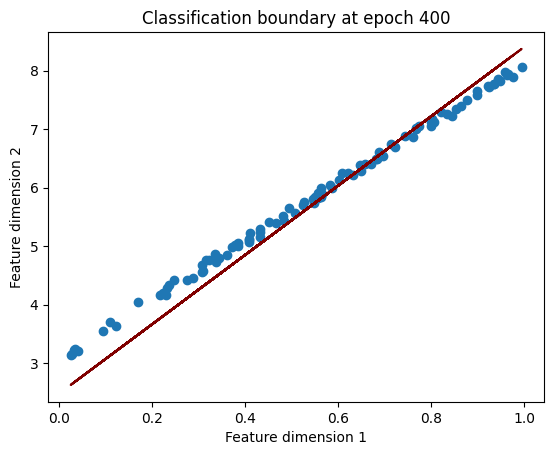

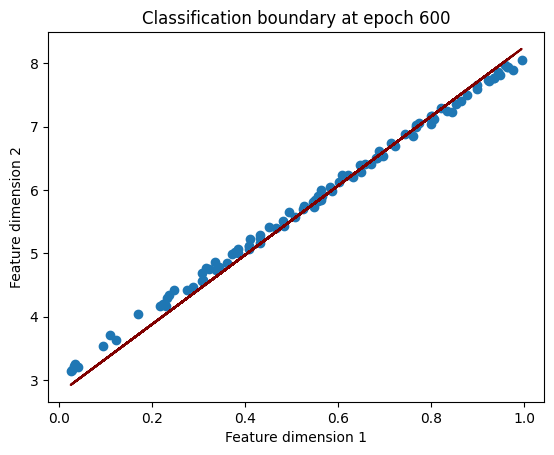

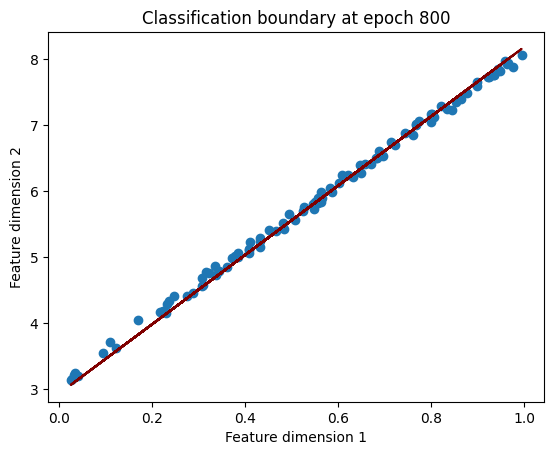

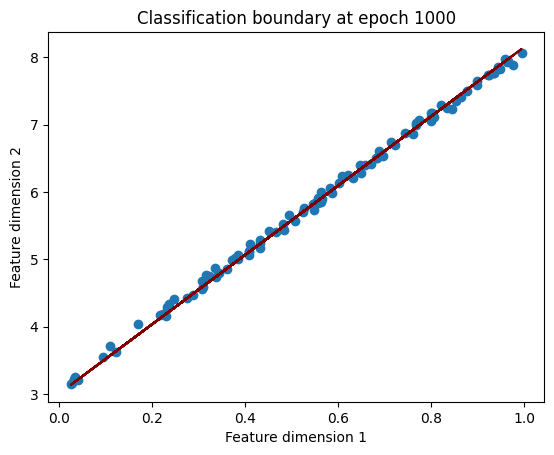

In [ ]:
import torch
import matplotlib.pyplot as plt

x=torch.FloatTensor(100,).uniform_(0,1)
y=5*x+3
y=torch.add(y,torch.FloatTensor(100,).uniform_(0,0.2))

w=torch.randn(1)
b=torch.randn(1)
print("Initially, w = ", "{:.4f}".format(w[0]))

def predict(x):
  return w*x+b

def loss(y,y_hat):
  return ((y-y_hat)**2).mean()

def gradients(x,y,y_hat):
  return -(torch.dot(2*x,(y-y_hat))).mean(), -2*(y-y_hat).mean()

lr=0.01
no_epochs=1000

for epoch in range(no_epochs):
  y_hat=predict(x)
  l=loss(y,y_hat)
  dw, db=gradients(x,y,y_hat)
  w-=lr*dw
  b-=lr*db
  if (epoch+1)%100==0:
    print("At itertion ", epoch+1, ", w = ", "{:.4f}".format(w[0]),", b = ", "{:.4f}".format(b[0]),", loss = ", "{:.4f}".format(l), " prediction = ","{:.4f}".format(predict(10)[0]), " actual = ","{:.4f}".format(5*10+3))

  if (epoch+1)%200==0:
    plt.figure()
    plt.scatter(x,y)
    plt.plot(x,predict(x), color ='#800000')
    plt.xlabel("Feature dimension 1")
    plt.ylabel("Feature dimension 2")
    plt.title("Classification boundary at epoch "+str(epoch+1))

Implementation using **Torch.nn**, **autograd** and **torch.nn**

At itertion  400 , w =  4.3175 , b =  3.5090 , loss =  0.0380
At itertion  800 , w =  4.7257 , b =  3.2718 , loss =  0.0080


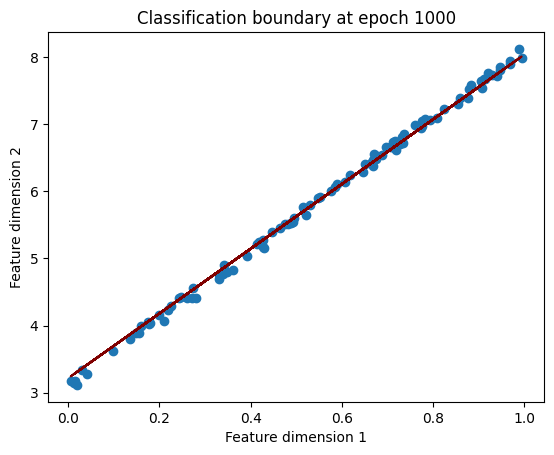

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

X = torch.FloatTensor(100,1).uniform_(0, 1)
Y = X*5+3
Y = torch.add(Y, torch.FloatTensor(100,1).uniform_(0, .2))

X_test = torch.tensor([10], dtype = torch.float32)
in_dimension = X.shape[1]
out_dimension = Y.shape[1]

model = nn.Linear(in_features = in_dimension, out_features = out_dimension, bias= True)
lr = 0.02
no_epochs = 1000

loss = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = lr)

for epoch in range(no_epochs):
    Y_p = model(X) # forwrd pass
    l = loss(Y,Y_p) # loss
    l.backward()

    optimizer.step() # update the step
    optimizer.zero_grad() # empty .grad

    [w,b]= model.parameters()
    if (epoch+1)%400 == 0:
      print("At itertion ", epoch+1, ", w = ", "{:.4f}".format(w.item()),", b = ", "{:.4f}".format(b.item()),", loss = ", "{:.4f}".format(l))


    if (epoch+1)%1000 == 0:
      plt.figure()
      plt.scatter(X,Y)
      plt.plot(X,model(X).detach().numpy(), color ='#800000')
      plt.xlabel("Feature dimension 1")
      plt.ylabel("Feature dimension 2")
      plt.title("Classification boundary at epoch "+str(epoch+1))

# Creating custom layers

steps:
1.  Subclassing from torch.nn.Module
2.  Define Constructor
3.  Define forward pass

In [ ]:
import torch
import torch.nn as nn

class MyLinearLayer(nn.Module):
  def __init__(self,size_in,size_out):
    super().__init__()
    self.size_in, self.size_out=size_in, size_out
    weights=torch.Tensor(size_out,size_in)
    self.weights=nn.Parameter(weights)
    bias=torch.Tensor(size_out)
    self.bias=nn.Parameter(bias)

    nn.init.normal_(self.weights, mean=0.0, std=1.0)
    nn.init.normal(self.bias, mean=0.0, std=1.0)

  def forward(self,x):
    w_times_x=torch.matmul(x,self.weights)
    y=w_times_x+self.bias
    return y

In [ ]:
layer=MyLinearLayer(5,1)

print(layer.weights)
print(layer.bias)

Parameter containing:
tensor([[ 0.6311, -0.1665, -0.1618,  0.4320,  1.8065]], requires_grad=True)
Parameter containing:
tensor([1.9510], requires_grad=True)


/tmp/ipython-input-3245451462.py:14: FutureWarning: `nn.init.normal` is now deprecated in favor of `nn.init.normal_`.
  nn.init.normal(self.bias, mean=0.0, std=1.0)


/tmp/ipython-input-3245451462.py:14: FutureWarning: `nn.init.normal` is now deprecated in favor of `nn.init.normal_`.
  nn.init.normal(self.bias, mean=0.0, std=1.0)


At itertion  500 , w =  4.4126 , b =  3.3972 , loss =  0.0387
At itertion  1000 , w =  4.7380 , b =  3.2353 , loss =  0.0109
At itertion  1500 , w =  4.8896 , b =  3.1599 , loss =  0.0049
At itertion  2000 , w =  4.9603 , b =  3.1247 , loss =  0.0036
At itertion  2500 , w =  4.9932 , b =  3.1083 , loss =  0.0033
At itertion  3000 , w =  5.0085 , b =  3.1007 , loss =  0.0033
At itertion  3500 , w =  5.0156 , b =  3.0972 , loss =  0.0032
At itertion  4000 , w =  5.0190 , b =  3.0955 , loss =  0.0032
At itertion  4500 , w =  5.0205 , b =  3.0947 , loss =  0.0032
At itertion  5000 , w =  5.0212 , b =  3.0944 , loss =  0.0032


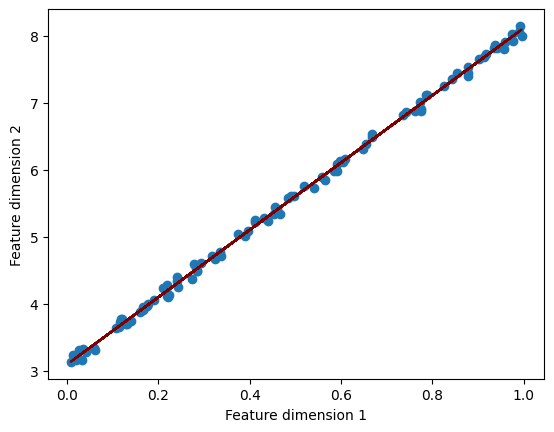

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# generate data for y = 5x+3
X = torch.FloatTensor(100,1).uniform_(0, 1)
Y = X*5+3
Y = torch.add(Y, torch.FloatTensor(100,1).uniform_(0, .2))

X_test = torch.tensor([10], dtype = torch.float32)

in_dimension = 1
out_dimension = 1

# define model
model = MyLinearLayer(1,1)
lr = 0.01
no_epochs = 5000
loss = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = lr)

for epoch in range(no_epochs):
    Y_p = model(X) # forwrd pass
    l = loss(Y,Y_p) # loss
    l.backward()

    optimizer.step()
    optimizer.zero_grad()

    [w,b]= model.parameters()
    if (epoch+1)%500 == 0:
      print("At itertion ", epoch+1, ", w = ", "{:.4f}".format(w.item()),", b = ", "{:.4f}".format(b.item()),", loss = ", "{:.4f}".format(l))


    if (epoch+1)%5000 == 0:
      plt.figure()
      plt.scatter(X,Y)
      plt.plot(X,model(X).detach().numpy(), color ='#800000')
      plt.xlabel("Feature dimension 1")
      plt.ylabel("Feature dimension 2")

# Perceptron

# Single layer perceptron for binary classification

epoch: 100, loss = 0.4788
epoch: 200, loss = 0.4035
epoch: 300, loss = 0.1685
epoch: 400, loss = 0.1253
epoch: 500, loss = 0.1095
epoch: 600, loss = 0.0999
epoch: 700, loss = 0.0935
epoch: 800, loss = 0.0889
epoch: 900, loss = 0.0854
epoch: 1000, loss = 0.0827


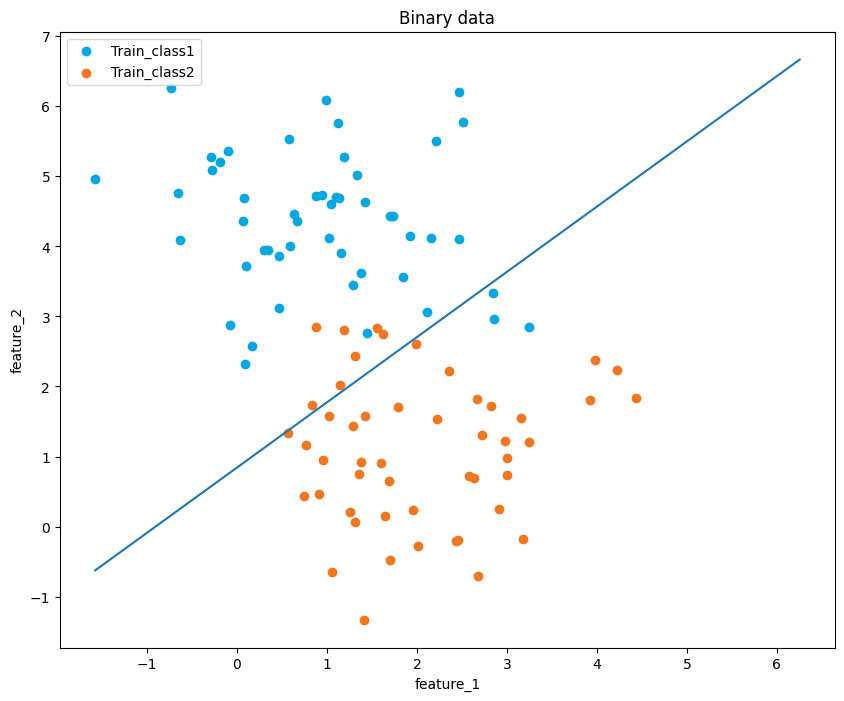

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import make_blobs
import torch.nn.functional as F

# generate data
X,y=make_blobs(n_samples=100,centers=2,n_features=2,random_state=0)
X=torch.tensor(X,dtype=torch.float32)
y=torch.tensor(y,dtype=torch.float32)
y=y.view(y.shape[0],1)

in_dimension=2
out_dimension=1

class Model(nn.Module):
  def __init__(self,in_dimension,out_dimension):
    super(Model,self).__init__()
    self.linear=nn.Linear(in_dimension,1)

  def forward(self,x):
    y_pred=torch.sigmoid(self.linear(x))
    return y_pred

model=Model(in_dimension,out_dimension)
num_epochs = 1000
learning_rate = 0.01
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

for epoch in range(num_epochs):
    y_pred = model(X)
    loss=criterion(y_pred,y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    if (epoch+1) % 100== 0:
        print(f'epoch: {epoch+1}, loss = {loss.item():.4f}')

[w,b] = model.parameters()
x_min = X.min().view(1, 1)
y_min = ( (-(w[0][0] * x_min) - b[0]) / w[0][1])
x_max = X.max().view(1, 1)
y_max = ( (-(w[0][0] * x_max) - b[0]) / w[0][1] )

fig = plt.figure(figsize=(10, 8))

plt.scatter(X[:, 0][y[:,0] == 0], X[:, 1][y[:,0]== 0], facecolors = '#00A7E1', edgecolor = '#00A7E1',marker = 'o', label = "Train_class1")
plt.scatter(X[:, 0][y[:,0] == 1], X[:, 1][y[:,0] == 1],facecolors='#F17720',edgecolor = '#F17720',marker = 'o',label = "Train_class2")
plt.plot(torch.cat((x_min, x_max)), torch.cat((y_min.detach(), y_max.detach())))
plt.xlabel("feature_1")
plt.ylabel("feature_2")
plt.title('Binary data')
plt.legend()

Two approaches to create network in pytorch
1.  Sequential
2.  Module

In [ ]:
import torch
import torch.nn as nn

myNetwork = nn.Sequential(
  nn.Linear(5, 7),
  nn.Tanh(),
  nn.Linear(7, 2)
)

def init_weights(m):
  if type(m) == nn.Linear:
    nn.init.xavier_uniform_(m.weight)
    m.bias.data.fill_(0.0)

myNetwork.apply(init_weights)

Sequential(
  (0): Linear(in_features=5, out_features=7, bias=True)
  (1): Tanh()
  (2): Linear(in_features=7, out_features=2, bias=True)
)

In [ ]:
import torch
import torch.nn as nn

class myNetwork(nn.Module):
  def __init__(self):
    super(myNetwork, self).__init__()
    self.hid = nn.Linear(5, 7)  # 5-7-2
    self.out = nn.Linear(7, 2)

    nn.init.xavier_uniform_(self.hid.weight)
    nn.init.zeros_(self.hid.bias)
    nn.init.xavier_uniform_(self.out.weight)
    nn.init.zeros_(self.out.bias)

  def forward(self, x):
    z = torch.tanh(self.hid(x))
    z = self.out(z)  # no softmax. see CrossEntropyLoss()
    return z

model = myNetwork()
model

myNetwork(
  (hid): Linear(in_features=5, out_features=7, bias=True)
  (out): Linear(in_features=7, out_features=2, bias=True)
)

# Multilayer Perceptron

epoch: 100, loss = 0.5966
epoch: 200, loss = 0.4006
epoch: 300, loss = 0.2645
epoch: 400, loss = 0.1923
epoch: 500, loss = 0.1518
epoch: 600, loss = 0.1263
epoch: 700, loss = 0.1082
epoch: 800, loss = 0.0953
epoch: 900, loss = 0.0857
epoch: 1000, loss = 0.0783
epoch: 1100, loss = 0.0724
epoch: 1200, loss = 0.0677
epoch: 1300, loss = 0.0638
epoch: 1400, loss = 0.0604
epoch: 1500, loss = 0.0575
epoch: 1600, loss = 0.0550
epoch: 1700, loss = 0.0528
epoch: 1800, loss = 0.0508
epoch: 1900, loss = 0.0491
epoch: 2000, loss = 0.0475
accuracy: 95.6140


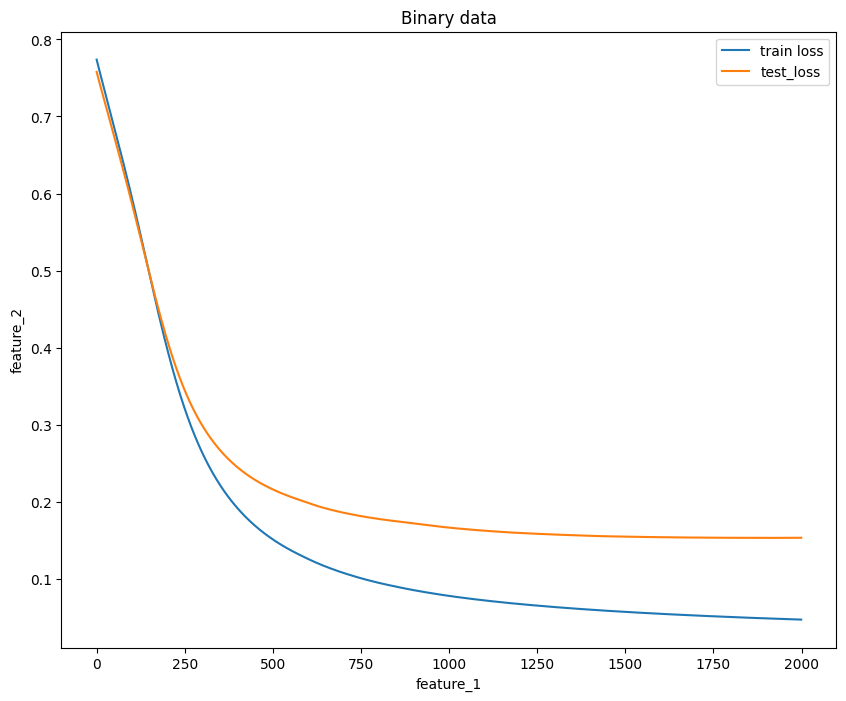

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 0) Prepare data
bc = datasets.load_breast_cancer()
X, y = bc.data, bc.target

n_samples, n_features = X.shape

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

# scale
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

X_train = torch.from_numpy(X_train.astype(np.float32))
X_test = torch.from_numpy(X_test.astype(np.float32))
y_train = torch.from_numpy(y_train.astype(np.float32))
y_test = torch.from_numpy(y_test.astype(np.float32))

y_train = y_train.view(y_train.shape[0], 1)
y_test = y_test.view(y_test.shape[0], 1)

# 1) Model
# Linear model f = wx + b , sigmoid at the end
# class Model(nn.Module):
#     def __init__(self, n_input_features):
#         super(Model, self).__init__()
#         self.linear = nn.Linear(n_input_features, 1)

#     def forward(self, x):
#         y_pred = torch.sigmoid(self.linear(x))
#         return y_pred

class Model(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(Model, self).__init__()
        self.input_size = input_size
        self.l1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.l2 = nn.Linear(hidden_size, num_classes)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out = self.l1(x)
        out = self.relu(out)
        out = self.l2(out)
        out = self.sigmoid(out)
        # no activation and no softmax at the end
        return out


model = Model(n_features,10,1)

# 2) Loss and optimizer
num_epochs = 2000
learning_rate = 0.01
criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# 3) Training loop
train_loss = []
test_loss = []
ep = []
for epoch in range(num_epochs):
    # Forward pass and loss
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)

    # Backward pass and update
    loss.backward()
    optimizer.step()

    # zero grad before new step
    optimizer.zero_grad()

    if (epoch+1) % 100 == 0:
        print(f'epoch: {epoch+1}, loss = {loss.item():.4f}')

    with torch.no_grad():
        y_test_pred = model(X_test)
        test_l = criterion(y_test_pred,y_test)
        # _, predicted = torch.max(y_pred.data, 1)
        ep.append(epoch)
        train_loss.append(loss.item())
        test_loss.append(test_l.item())

fig = plt.figure(figsize=(10, 8))
plt.plot(ep,train_loss)
plt.plot(ep,test_loss)
plt.xlabel("feature_1")
plt.ylabel("feature_2")
plt.title('Binary data')
plt.legend(["train loss","test_loss"])

with torch.no_grad():
    y_predicted = model(X_test)
    y_predicted_cls = y_predicted.round()
    acc = 100*y_predicted_cls.eq(y_test).sum() / float(y_test.shape[0])
    print(f'accuracy: {acc.item():.4f}')

# Loss Functions:
1. Regression Loss Function
2. Classification Loss Function

1. Mean Absolute Error(L1 Loss Function): torch.nn.L1Loss

In [ ]:
import torch
y_pred=torch.tensor([0.000,0.100,0.200])
y_true=torch.tensor([0.000,0.200,0.250])

def mae(y_true,y_pred):
  difference=y_true-y_pred
  abs_difference=torch.abs(difference)
  mean_absolute_error=abs_difference.mean()
  return mean_absolute_error

mae_value=mae(y_true,y_pred)
print("Custom MAE Error is: ",mae_value.item())

mae_loss=torch.nn.L1Loss()
loss=mae_loss(y_true,y_pred)
print("PyTorch torch.nn MAE Error is: ",loss.item())

Custom MAE Error is:  0.05000000074505806
PyTorch torch.nn MAE Error is:  0.05000000074505806


2. Mean Square Error(L2 Loss Function): torch.nn.MSELoss

In [ ]:
import torch
input = torch.randn(3, 4, requires_grad=True)
target = torch.randn(3, 4)

def mse(y_true,y_pred):
  difference=y_true-y_pred
  squired_difference=difference**2
  mean_squared_error=squired_difference.mean()
  return mean_squared_error

mse_value=mse(target,input)
print("Custom MSE Error is: ",mse_value.item())

mse_loss = torch.nn.MSELoss()
output = mse_loss(input, target)

# print('input -: ', input)
# print('target -: ', target)
print('torch.nn output -: ', output.item())

Custom MSE Error is:  1.7879751920700073
torch.nn output -:  1.7879751920700073


3. Binary Cross Entropy:  **torch.nn.BCELoss**

\begin{equation}
BCEloss(y,\hat{y}) = \frac{1}{N}\sum_{i = 1}^{N}(-y_i*\log{\hat{y}_i}-(1-y_i)*\log({1-\hat{y}_i}))
\end{equation}


In [ ]:
import torch

y_pred = torch.tensor([0.1580, 0.4137, 0.2285])
y_true = torch.tensor([0.0, 1.0, 0.0]) #2 labels: (0,1)

def BCE(y_pred, y_true):
    total_bce_loss = torch.sum(-y_true * torch.log(y_pred) - (1 - y_true) * torch.log(1 - y_pred))
    # Getting the mean BCE loss
    num_of_samples = y_pred.shape[0]
    mean_bce_loss = total_bce_loss / num_of_samples

    return mean_bce_loss

bce_value = BCE(y_pred, y_true)
print ("Custom BCE error is: " , bce_value.item())

#using torch.nn.BCELoss
bce_loss = torch.nn.BCELoss()
output = bce_loss(y_pred, y_true)
print ("torch.nn BCE loss is: ",output.item())


Custom BCE error is:  0.43800267577171326
torch.nn BCE loss is:  0.43800270557403564



4. Cross-Entropy Loss Function:  **torch.nn.CrossEntropyLoss**


\begin{equation}
CEloss(y,\hat{y}) = \frac{1}{N}\sum_{i = 1}^{N}(-y_i*\log{\hat{y}_i})
\end{equation}

In [ ]:
import torch

y_pred = torch.randn(3, 5, requires_grad=True)
y_true = torch.empty(3, dtype=torch.long).random_(5)

def log_softmax(x):
    return torch.log(torch.exp(x) / torch.sum(torch.exp(x), dim=1, keepdim=True))

def CrossEntropyLoss(outputs, targets):
    num_examples = targets.shape[0]
    batch_size = outputs.shape[0]
    outputs = log_softmax(outputs)
    outputs = outputs[range(batch_size), targets]

    return - torch.sum(outputs)/num_examples

ce_value = CrossEntropyLoss(y_pred, y_true)
print ("Custom CE error is: " , ce_value.item())

#using torch.nn.CrossEntropyLoss
ce_loss = torch.nn.CrossEntropyLoss()
output = ce_loss(y_pred, y_true)
print ("torch.nn CE loss is: ",output.item())

Custom CE error is:  2.5141701698303223
torch.nn CE loss is:  2.5141701698303223


5. KL-divergence: **torch.nn.KLDivLoss**

\begin{equation}
KLDloss(y,\hat{y}) = \frac{1}{N}\sum_{i = 1}^{N}(y*\log{(y/\hat{y})})
\end{equation}

In [ ]:
import torch
y_pred = torch.randn(2, 3, requires_grad=True)
y_true = torch.randn(2, 3)

def KLDivLoss(y_pred, y_true):
  number_of_samples=y_pred.shape[0]
  total_kld_loss=torch.sum(y_true*torch.log(y_true/y_pred))
  mean_kld_loss=total_kld_loss/number_of_samples
  return mean_kld_loss

kld_value = KLDivLoss(y_pred, y_true)
print ("Custom KLD error is: " , kld_value)

kld_loss = torch.nn.KLDivLoss(reduction = 'batchmean')
output = kld_loss(y_pred, y_true)

# print('input tensor: ', y_pred)
# print('target tensor: ', y_true)
print('torch.nn Loss: ', output)

Custom KLD error is:  tensor(nan, grad_fn=<DivBackward0>)
torch.nn Loss:  tensor(nan, grad_fn=<DivBackward0>)


# Define NNs, criterion functions, optimizer, activation functions and training loop on MNIST dataset



using **nn.Module**

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets
import torch.nn.functional as F
import matplotlib.pylab as plt
import numpy as np

In [ ]:
# We create a subclass of nn.Module class for creating a new network
class Net(nn.Module):
  def __init__(self,D_in,H1,H2,D_out):
    super(Net,self).__init__()
    self.linear1=nn.Linear(D_in,H1)
    self.linear2=nn.Linear(H1,H2)
    self.linear3=nn.Linear(H2,D_out)
  def forward(self,x):
    x=torch.sigmoid(self.linear1(x))
    x=torch.sigmoid(self.linear2(x))
    x=self.linear3(x)
    return x

In [ ]:
# Another way to creat a model is using nn.Sequential
model1=nn.Sequential(nn.Linear(784,50),
                     nn.Sigmoid(),
                     nn.Linear(50,50),
                     nn.Sigmoid(),
                     nn.Linear(50,10))
model1.parameters

<bound method Module.parameters of Sequential(
  (0): Linear(in_features=784, out_features=50, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=50, out_features=50, bias=True)
  (3): Sigmoid()
  (4): Linear(in_features=50, out_features=10, bias=True)
)>

In [ ]:
## create another neural network using tanh activation function
class NetTanh(nn.Module):

    # Constructor
    def __init__(self, D_in, H1, H2, D_out):
        super(NetTanh, self).__init__()
        self.linear1 = nn.Linear(D_in, H1)
        self.linear2 = nn.Linear(H1, H2)
        self.linear3 = nn.Linear(H2, D_out)

    # Prediction
    def forward(self, x):
        x = torch.tanh(self.linear1(x))
        x = torch.tanh(self.linear2(x))
        x = self.linear3(x)
        return x

In [ ]:
# Create the model class using Relu as a activation function

class NetRelu(nn.Module):

    # Constructor
    def __init__(self, D_in, H1, H2, D_out):
        super(NetRelu, self).__init__()
        self.linear1 = nn.Linear(D_in, H1)
        self.linear2 = nn.Linear(H1, H2)
        self.linear3 = nn.Linear(H2, D_out)

    # Prediction
    def forward(self, x):
        x = torch.relu(self.linear1(x))
        x = torch.relu(self.linear2(x))
        x = self.linear3(x)
        return x

In [ ]:
# Creating the datasets
train_data=dsets.MNIST(root='./data',train=True,download=True,transform=transforms.ToTensor())
test_data=dsets.MNIST(root='./data',train=False,download=True,transform=transforms.ToTensor())

# Creating the dataloader
train_loader=torch.utils.data.DataLoader(dataset=train_data,batch_size=2000,shuffle=True)
test_loader=torch.utils.data.DataLoader(dataset=test_data,batch_size=5000,shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 35.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 2.16MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.56MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.08MB/s]


In [ ]:
for i,j in train_loader:
  print(i.shape)
  print(j.shape)

torch.Size([2000, 1, 28, 28])
torch.Size([2000])
torch.Size([2000, 1, 28, 28])
torch.Size([2000])
torch.Size([2000, 1, 28, 28])
torch.Size([2000])
torch.Size([2000, 1, 28, 28])
torch.Size([2000])
torch.Size([2000, 1, 28, 28])
torch.Size([2000])
torch.Size([2000, 1, 28, 28])
torch.Size([2000])
torch.Size([2000, 1, 28, 28])
torch.Size([2000])
torch.Size([2000, 1, 28, 28])
torch.Size([2000])
torch.Size([2000, 1, 28, 28])
torch.Size([2000])
torch.Size([2000, 1, 28, 28])
torch.Size([2000])
torch.Size([2000, 1, 28, 28])
torch.Size([2000])
torch.Size([2000, 1, 28, 28])
torch.Size([2000])
torch.Size([2000, 1, 28, 28])
torch.Size([2000])
torch.Size([2000, 1, 28, 28])
torch.Size([2000])
torch.Size([2000, 1, 28, 28])
torch.Size([2000])
torch.Size([2000, 1, 28, 28])
torch.Size([2000])
torch.Size([2000, 1, 28, 28])
torch.Size([2000])
torch.Size([2000, 1, 28, 28])
torch.Size([2000])
torch.Size([2000, 1, 28, 28])
torch.Size([2000])
torch.Size([2000, 1, 28, 28])
torch.Size([2000])
torch.Size([2000, 1,

In [ ]:
i.view(-1,784) # this operation effectively flattens each (1, 28, 28) image into a 1D vector of 784 pixels.
               # If i originally had a shape like (batch_size, 1, 28, 28), after view(-1, 784), its shape becomes (batch_size, 784)

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [ ]:
train_data[0][0].shape

torch.Size([1, 28, 28])

In [ ]:
train_data[0][1] #label of the (0,1)th inage

5

The label of this image is: 5


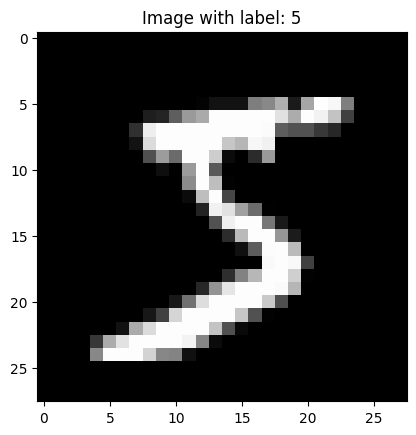

In [ ]:
# Get the first image (data) and its label
image, label = train_data[0]

print(f"The label of this image is: {label}")

# Display the image
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"Image with label: {label}")
plt.show()

* Define the training function

In [ ]:
def train(model,criterion,train_loader,test_loader,optimizer,epochs=100):
  loss_and_accuracy={'training_loss':[],'validation_accuracy':[]}
  for epoch in range(epochs):
    for i,(x,y) in enumerate(train_loader):
      optimizer.zero_grad()
      z=model(x.view(-1,28*28))
      loss=criterion(z,y)
      loss.backward()
      optimizer.step()
      loss_and_accuracy["training_loss"].append(loss.data.item())

    correct=0
    for x,y in test_loader:
      z=model(x.view(-1,28*28))
      _,label=torch.max(z,1) # to find the maximum score among all the classes
      correct+=(label==y).sum().item()

    accuracy=100*(correct/len(test_data))
    loss_and_accuracy["validation_accuracy"].append(accuracy)
  return loss_and_accuracy

* Define nural network -> Define loss function/criterion function -> Define optimizer -> Also set the parameters for the nn -> set the number of epochs

In [ ]:
input_dim=28*28
hidden_dim1=50
hidden_dim2=50
output_dim=10

* Training the network using the Sigmoid activation function

In [ ]:
epochs=10
learning_rate=0.01
criterion=nn.CrossEntropyLoss()
model=Net(input_dim,hidden_dim1,hidden_dim2,output_dim)
optimizer=torch.optim.SGD(model.parameters(),lr=learning_rate)

In [ ]:
training_results=train(model,criterion,train_loader,test_loader,optimizer,epochs)

* Training the network using the tanh activation function

In [ ]:
learning_rate=0.01
model_Tanh=NetTanh(input_dim,hidden_dim1,hidden_dim1,output_dim)
optimizer=torch.optim.SGD(model_Tanh.parameters(),lr=learning_rate)
training_results_tanh=train(model_Tanh,criterion,train_loader,test_loader,optimizer,epochs)

* Training the network using the ReLU function

In [ ]:
learning_rate=0.01
model_Relu=NetRelu(input_dim,hidden_dim1,hidden_dim1,output_dim)
optimizer=torch.optim.SGD(model_Relu.parameters(),lr=learning_rate)
training_results_relu=train(model_Relu,criterion,train_loader,test_loader,optimizer,epochs)

Lets compare the results

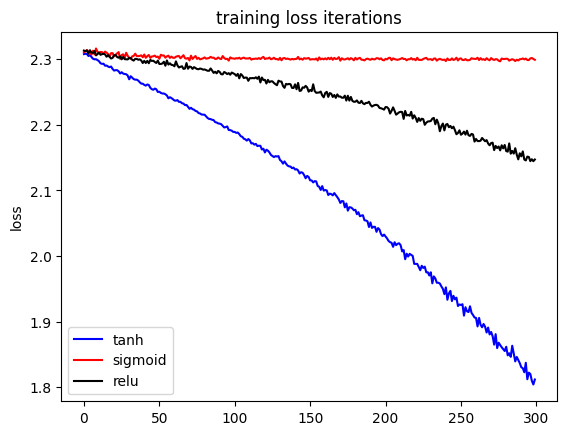

In [ ]:
plt.plot(training_results_tanh['training_loss'], label='tanh', color="blue")
plt.plot(training_results['training_loss'], label='sigmoid', color="red" )
plt.plot(training_results_relu['training_loss'], label='relu', color="black")
plt.ylabel('loss')
plt.title('training loss iterations')
plt.legend()

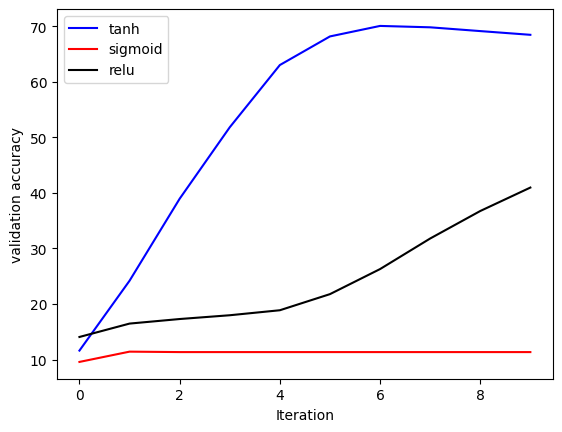

In [ ]:

plt.plot(training_results_tanh['validation_accuracy'], label = 'tanh', color="blue")
plt.plot(training_results['validation_accuracy'], label = 'sigmoid', color="red")
plt.plot(training_results_relu['validation_accuracy'], label = 'relu', color="black")
plt.ylabel('validation accuracy')
plt.xlabel('Iteration')
plt.legend()

saving and loading models (using **state_dict**)

In [ ]:
# Print model's state_dict
print("Model's state_dict:")
for param_tensor in model.state_dict():
     print(param_tensor, "\t", model.state_dict()[param_tensor].size())

Model's state_dict:
linear1.weight 	 torch.Size([50, 784])
linear1.bias 	 torch.Size([50])
linear2.weight 	 torch.Size([50, 50])
linear2.bias 	 torch.Size([50])
linear3.weight 	 torch.Size([10, 50])
linear3.bias 	 torch.Size([10])


In [ ]:
# Print model_Tanh's state_dict
print("Model_Tanh's state_dict:")
for param_tensor in model_Tanh.state_dict():
     print(param_tensor, "\t", model_Tanh.state_dict()[param_tensor].size())

Model_Tanh's state_dict:
linear1.weight 	 torch.Size([50, 784])
linear1.bias 	 torch.Size([50])
linear2.weight 	 torch.Size([50, 50])
linear2.bias 	 torch.Size([50])
linear3.weight 	 torch.Size([10, 50])
linear3.bias 	 torch.Size([10])


In [ ]:
# Print optimizer's state_dict
print("Optimizer's state_dict:")
for var_name in optimizer.state_dict():
    print(var_name, "\t", optimizer.state_dict()[var_name])

Optimizer's state_dict:
state 	 {}
param_groups 	 [{'lr': 0.01, 'momentum': 0, 'dampening': 0, 'weight_decay': 0, 'nesterov': False, 'maximize': False, 'foreach': None, 'differentiable': False, 'fused': None, 'params': [0, 1, 2, 3, 4, 5]}]


In [ ]:
# "inference" is the crucial phase where a trained model applies its learned knowledge to make predictions, classifications, or decisions
#on new, unseen data in a real-world setting

# Specify a path
PATH = "state_dict_model.pt" #A common PyTorch convention is to save models using either a .pt or .pth file extension.

# Save
torch.save(model.state_dict(), PATH)

# Load
model = Net(input_dim, hidden_dim1, hidden_dim2, output_dim)
model.load_state_dict(torch.load(PATH))

model.eval()
#Remember too, that you must call model.eval() to set dropout and batch normalization layers to evaluation mode before running inference.
#Failing to do this will yield inconsistent inference results.


Net(
  (linear1): Linear(in_features=784, out_features=50, bias=True)
  (linear2): Linear(in_features=50, out_features=50, bias=True)
  (linear3): Linear(in_features=50, out_features=10, bias=True)
)

# save general check point

In [ ]:
# #Additional information
# EPOCH = 5
# PATH = "model.pt"
# LOSS = 0.4

# torch.save({
#             'epoch': EPOCH,
#             'model_state_dict': net.state_dict(),
#             'optimizer_state_dict': optimizer.state_dict(),
#             'loss': LOSS,
#             }, PATH)



# model = Net()
# optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

# checkpoint = torch.load(PATH)
# model.load_state_dict(checkpoint['model_state_dict'])
# optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
# epoch = checkpoint['epoch']
# loss = checkpoint['loss']

# model.eval()
# # - or -
# model.train()

# Another way to define NNs when we need to experiment with different neurons and layers

using **nn.ModuleList()**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from matplotlib.colors import ListedColormap
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(1)# It initializes the random number generator on the CPU with a specific seed value
                    #  will produce the exact same sequence of 'random' numbers every time you run the code

In [ ]:
# Define the function to plot the diagram

def plot_decision_regions_3class(model, data_set):
    cmap_light = ListedColormap(['#d7bde2', '#f4d03f', '#e59866'])
    cmap_bold = ListedColormap(['#633974', '#7d6608', '#784212'])
    X = data_set.x.numpy()
    y = data_set.y.numpy()
    h = .02
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    XX = torch.Tensor(np.c_[xx.ravel(), yy.ravel()])
    # ravel(): Flattened array having same type as the Input array and and order as per choice.
    # np.c_ : add along second axis.
    _, yhat = torch.max(model(XX), 1)
    yhat = yhat.numpy().reshape(xx.shape)
    plt.pcolormesh(xx, yy, yhat, cmap=cmap_light)
    #pcolormesh() : function in pyplot module of matplotlib library is used to create a pseudocolor plot
    #with a non-regular rectangular grid.
    plt.plot(X[y[:] == 0, 0], X[y[:] == 0, 1], 'yo', label = 'y=0')
    plt.plot(X[y[:] == 1, 0], X[y[:] == 1, 1], 'r^', label = 'y=1')
    plt.plot(X[y[:] == 2, 0], X[y[:] == 2, 1], 'g<', label = 'y=2')
    plt.title("decision region")
    plt.legend()

* Create custom Dataloader

In [ ]:

### Source: http://cs231n.github.io/neural-networks-case-study/
class Data(Dataset):
    # Constructor
    def __init__(self, K=3, N=500):
        D = 2
        X = np.zeros((N * K, D)) # data matrix (each row = single example)
        y = np.zeros(N * K, dtype='uint8') # class labels
        for j in range(K):
          ix = range(N * j, N * (j + 1))
          r = np.linspace(0.0, 1, N) # radius
          t = np.linspace(j * 4, (j + 1) * 4, N) + np.random.randn(N) * 0.2 # theta
          X[ix] = np.c_[r * np.sin(t), r*np.cos(t)]
          y[ix] = j
        self.y = torch.from_numpy(y).type(torch.LongTensor)
        self.x = torch.from_numpy(X).type(torch.FloatTensor)
        self.len = y.shape[0]

    # Getter
    def __getitem__(self, index):
        return self.x[index], self.y[index]

    # Get Length
    def __len__(self):
        return self.len

    # Plot the diagram
    def plot_stuff(self):
        plt.plot(self.x[self.y[:] == 0, 0].numpy(), self.x[self.y[:] == 0, 1].numpy(), 'yo', label="y = 0")
        plt.plot(self.x[self.y[:] == 1, 0].numpy(), self.x[self.y[:] == 1, 1].numpy(), 'r^', label="y = 1")
        plt.plot(self.x[self.y[:] == 2, 0].numpy(), self.x[self.y[:] == 2, 1].numpy(), 'g<', label="y = 2")
        plt.legend()

* NN model using ModuleList()

In [ ]:
# Create Net model class

class Net(nn.Module):

    # Constructor
    def __init__(self, Layers):
        super(Net, self).__init__()
        self.hidden = nn.ModuleList()
        for input_size, output_size in zip(Layers, Layers[1:]):  # Layers = [3,5,5,5,5,2]
            self.hidden.append(nn.Linear(input_size, output_size))

    # Prediction
    def forward(self, x):
        L = len(self.hidden)
        for (l, linear_transform) in zip(range(L), self.hidden):
            if l < L - 1:
                x = torch.relu(linear_transform(x))
            else:
                x = linear_transform(x)
        return x

In [ ]:
# Define the function for training the model

def train(data_set, model, criterion, train_loader, optimizer, epochs=100):
    LOSS = []
    ACC = []
    for epoch in range(epochs):
        for x, y in train_loader:
            optimizer.zero_grad()
            yhat = model(x)
            loss = criterion(yhat, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            LOSS.append(loss.item())
        ACC.append(accuracy(model, data_set))
    return LOSS,ACC

# The function to calculate the accuracy

def accuracy(model, data_set):
    _, yhat = torch.max(model(data_set.x), 1)
    return (yhat == data_set.y).numpy().mean() # boolean tensor->numpy array(0's abd 1's)->mean

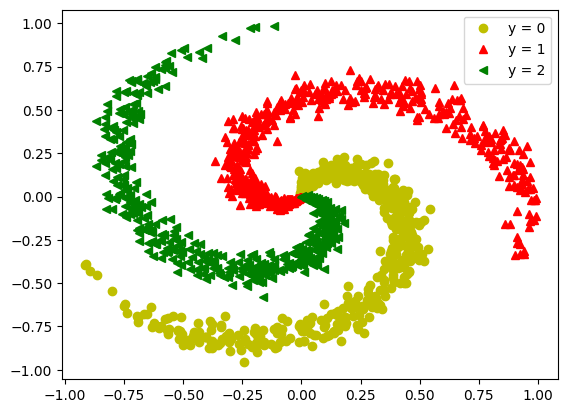

In [ ]:
# Create a Dataset object

data_set = Data()
data_set.plot_stuff()
data_set.y = data_set.y.view(-1) # data_set.y is already a 1D tensor (e.g., (1500,)), applying view(-1) won't change its shape.
                                # However, this is often done as a defensive measure to ensure that the tensor is indeed a flat, 1D vector.
                                # Some PyTorch loss functions (like nn.CrossEntropyLoss for classification) expect target labels to be provided as a 1D tensor,
                                # not as a column vector (e.g., (1500, 1)). So, view(-1) guarantees that the labels are in the expected format for these functions.

In [ ]:
# Train the model with 1 hidden layer with 50 neurons

Layers = [2, 50, 3]
model = Net(Layers)
learning_rate = 0.10
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
train_loader = DataLoader(dataset=data_set, batch_size=20)
criterion = nn.CrossEntropyLoss()
LOSS, ACC = train(data_set, model, criterion, train_loader, optimizer, epochs=100)

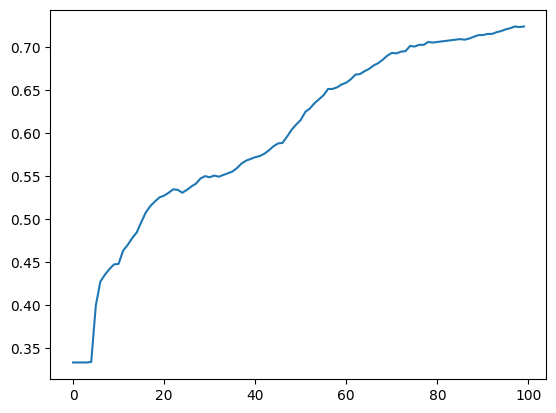

In [ ]:
plt.plot(ACC)

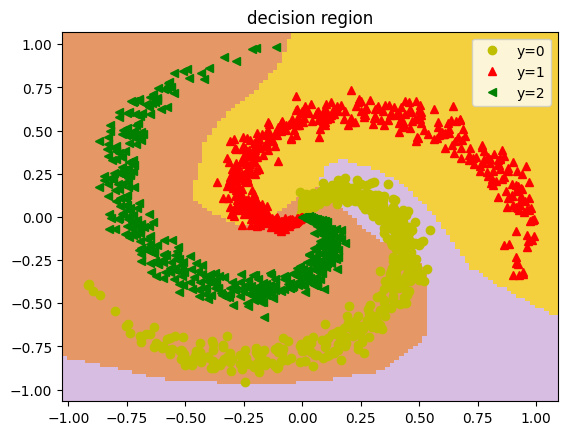

In [ ]:
# plot decision region

plot_decision_regions_3class(model, data_set)

In [ ]:
Net([3,3,4,3]).parameters

<bound method Module.parameters of Net(
  (hidden): ModuleList(
    (0): Linear(in_features=3, out_features=3, bias=True)
    (1): Linear(in_features=3, out_features=4, bias=True)
    (2): Linear(in_features=4, out_features=3, bias=True)
  )
)>

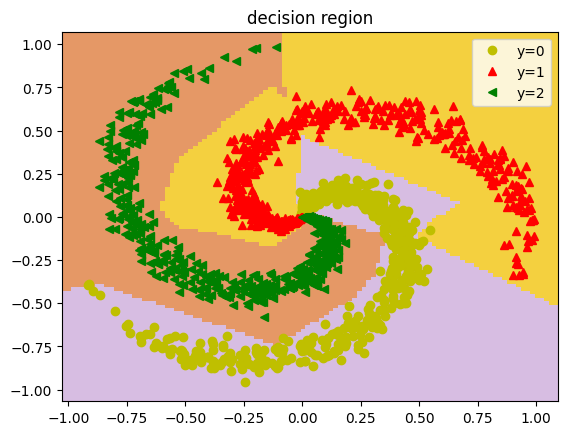

In [ ]:
# Train the model with 2 hidden layers with 20 neurons

Layers = [2, 10, 10, 3]
model = Net(Layers)
learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
train_loader = DataLoader(dataset=data_set, batch_size=20)
criterion = nn.CrossEntropyLoss()
LOSS, ACC = train(data_set, model, criterion, train_loader, optimizer, epochs=1000)

plot_decision_regions_3class(model, data_set)

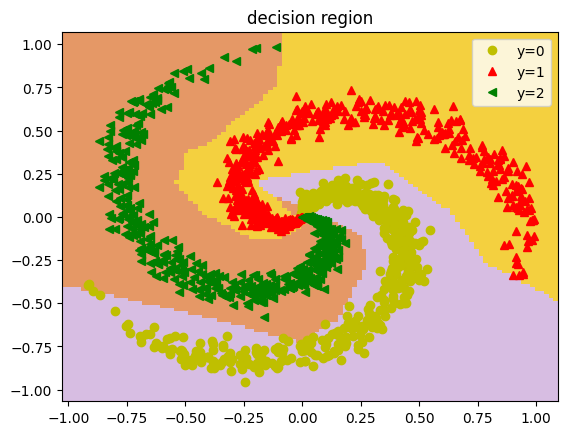

In [ ]:
# network with three hidden layers each with ten neurons
Layers = [2, 10, 10, 10, 3]
model = Net(Layers)
learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)
train_loader = DataLoader(dataset = data_set, batch_size = 20)
criterion = nn.CrossEntropyLoss()
LOSS, ACC = train(data_set, model, criterion, train_loader, optimizer, epochs = 1000)
plot_decision_regions_3class(model, data_set)

# NN with Batch-Normalization

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets
import torch.nn.functional as F
import matplotlib.pylab as plt
import numpy as np
torch.manual_seed(0)

# Neural Network Module with two hidden layers using Batch Normalization

class NetBatchNorm(nn.Module):

    # Constructor
    def __init__(self, in_size, n_hidden1, n_hidden2, out_size):
        super(NetBatchNorm, self).__init__()
        self.linear1 = nn.Linear(in_size, n_hidden1)
        self.linear2 = nn.Linear(n_hidden1, n_hidden2)
        self.linear3 = nn.Linear(n_hidden2, out_size)
        self.bn1 = nn.BatchNorm1d(n_hidden1)
        self.bn2 = nn.BatchNorm1d(n_hidden2)

    # Prediction
    def forward(self, x):
        x = torch.sigmoid(self.bn1(self.linear1(x)))
        x = torch.sigmoid(self.bn2(self.linear2(x)))
        x = self.linear3(x)
        return x
# In general, Batch Norm layer is usually added before ReLU(as mentioned in the Batch Normalization paper).
# But there is no real standard being followed as to where to add a Batch Norm layer.
# You can experiment with different settings and you may find different performances for each setting.

    # Activations, to analyze results
    def activation(self, x):
        out = []
        z1 = self.bn1(self.linear1(x))
        out.append(z1.detach().numpy().reshape(-1))
        a1 = torch.sigmoid(z1)
        out.append(a1.detach().numpy().reshape(-1).reshape(-1))
        z2 = self.bn2(self.linear2(a1))
        out.append(z2.detach().numpy().reshape(-1))
        a2 = torch.sigmoid(z2)
        out.append(a2.detach().numpy().reshape(-1))
        return out


# Neural Network Module with two hidden layers with out Batch Normalization
class Net(nn.Module):

    # Constructor
    def __init__(self, in_size, n_hidden1, n_hidden2, out_size):

        super(Net, self).__init__()
        self.linear1 = nn.Linear(in_size, n_hidden1)
        self.linear2 = nn.Linear(n_hidden1, n_hidden2)
        self.linear3 = nn.Linear(n_hidden2, out_size)

    # Prediction
    def forward(self, x):
        x = torch.sigmoid(self.linear1(x))
        x = torch.sigmoid(self.linear2(x))
        x = self.linear3(x)
        return x

    # function creates to analyze results what effect we get on output of the
    # activation function, after we apply batch normalization on the output of the linear layer and followed by the
    # the activation function.
    def activation(self, x):
        out = []
        z1 = self.linear1(x)
        out.append(z1.detach().numpy().reshape(-1))
        a1 = torch.sigmoid(z1)
        out.append(a1.detach().numpy().reshape(-1).reshape(-1))
        z2 = self.linear2(a1)
        out.append(z2.detach().numpy().reshape(-1))
        a2 = torch.sigmoid(z2)
        out.append(a2.detach().numpy().reshape(-1))
        return out


In [ ]:
# Define the function to train model

def train(model, criterion, train_loader, validation_loader, optimizer, epochs=100):
    i = 0
    loss_and_acc = {'training_loss':[], 'validation_accuracy':[]}

    for epoch in range(epochs):
        for i, (x, y) in enumerate(train_loader):
            model.train()
            optimizer.zero_grad()
            z = model(x.view(-1, 28 * 28))
            loss = criterion(z, y)
            loss.backward()
            optimizer.step()
            loss_and_acc['training_loss'].append(loss.data.item())

        correct = 0
        for x, y in validation_loader:
            model.eval()
            yhat = model(x.view(-1, 28 * 28))
            _, label = torch.max(yhat, 1)
            correct += (label == y).sum().item()

        accuracy = 100 * (correct / len(validation_dataset))
        loss_and_acc['validation_accuracy'].append(accuracy)

    return loss_and_acc

* Training MNIST dataset with the network containing batch normalization layer

In [ ]:
# load the train dataset
train_dataset = dsets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())

# load the train datase
validation_dataset = dsets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

# Create Data Loader for both train and validating
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=2000, shuffle=True)
validation_loader = torch.utils.data.DataLoader(dataset=validation_dataset, batch_size=5000, shuffle=False)

# Create the criterion function
criterion = nn.CrossEntropyLoss()

# Set the parameters
input_dim = 28 * 28
hidden_dim = 100
output_dim = 10

# Create model, optimizer and train the model
model_norm  = NetBatchNorm(input_dim, hidden_dim, hidden_dim, output_dim)
optimizer = torch.optim.Adam(model_norm.parameters(), lr = 0.1)
training_results_Norm=train(model_norm , criterion, train_loader, validation_loader, optimizer, epochs=5)


# Create model without Batch Normalization, optimizer and train the model
model = Net(input_dim, hidden_dim, hidden_dim, output_dim)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.1)
training_results = train(model, criterion, train_loader, validation_loader, optimizer, epochs=5)

* Result Analysys

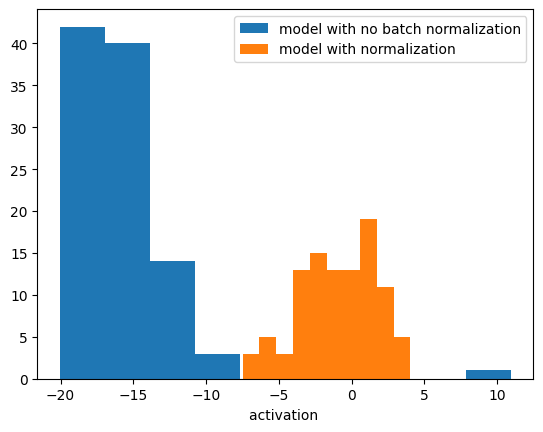

In [ ]:
model.eval()
model_norm.eval()
out=model.activation(validation_dataset[0][0].reshape(-1,28*28))
plt.hist(out[2],label='model with no batch normalization' )
out_norm=model_norm.activation(validation_dataset[0][0].reshape(-1,28*28))
plt.hist(out_norm[2],label='model with normalization')
plt.xlabel("activation ")
plt.legend()
plt.show()

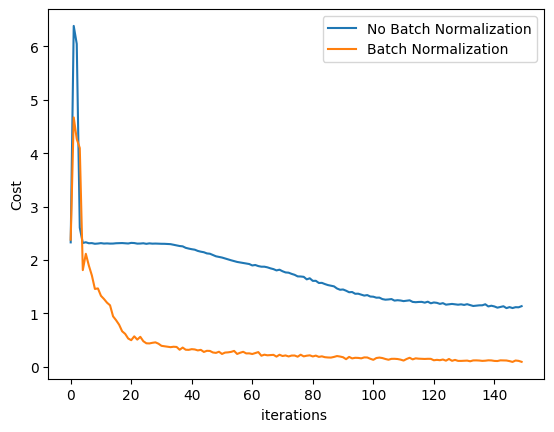

In [ ]:
### training loss comparison
# Plot the diagram to show the loss

plt.plot(training_results['training_loss'], label='No Batch Normalization')
plt.plot(training_results_Norm['training_loss'], label='Batch Normalization')
plt.ylabel('Cost')
plt.xlabel('iterations ')
plt.legend()
plt.show()

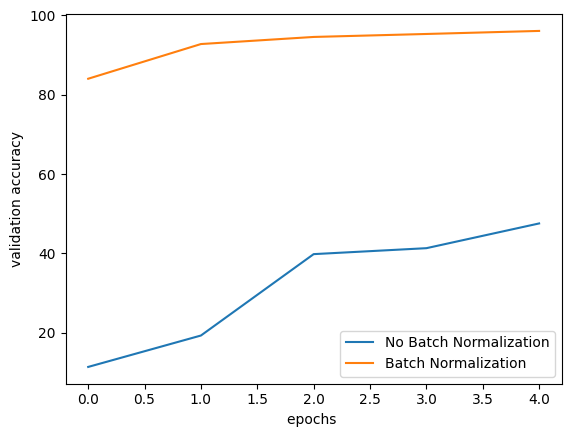

In [ ]:
### Comparison of accuracy

plt.plot(training_results['validation_accuracy'],label='No Batch Normalization')
plt.plot(training_results_Norm['validation_accuracy'],label='Batch Normalization')
plt.ylabel('validation accuracy')
plt.xlabel('epochs ')
plt.legend()
plt.show()

# DropOut

In [ ]:
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from matplotlib.colors import ListedColormap
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(0)

In [ ]:
# Define supplementary functions

def plot_decision_regions_3class(data_set, model=None):
    cmap_light = ListedColormap([ '#85c1e9','#f1c40f'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#00AAFF'])
    X = data_set.x.numpy()
    y = data_set.y.numpy()
    h = .02
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    newdata = np.c_[xx.ravel(), yy.ravel()]

    Z = data_set.multi_dim_poly(newdata).flatten()
    f = np.zeros(Z.shape)
    f[Z > 0] = 1
    f = f.reshape(xx.shape)
    if model != None:
        model.eval()
        XX = torch.Tensor(newdata)
        _, yhat = torch.max(model(XX), 1)
        yhat = yhat.numpy().reshape(xx.shape)
        plt.pcolormesh(xx, yy, yhat, cmap=cmap_light)
        plt.contour(xx, yy, f, cmap=plt.cm.Paired)
    else:
        plt.contour(xx, yy, f, cmap=plt.cm.Paired)
        plt.pcolormesh(xx, yy, f, cmap=cmap_light)

    plt.title("decision region vs True decision boundary")

# The function for calculating accuracy

def accuracy(model, data_set):
    _, yhat = torch.max(model(data_set.x), 1)
    return (yhat == data_set.y).numpy().mean()

In [ ]:
# Create data class for creating dataset object

class Data(Dataset):

    # Constructor
    def __init__(self, N_SAMPLES=1000, noise_std=0.15, train=True):
        a = np.matrix([-1, 1, 2, 1, 1, -3, 1]).T
        self.x = np.matrix(np.random.rand(N_SAMPLES, 2))
        self.f = np.array(a[0] + (self.x) * a[1:3] + np.multiply(self.x[:, 0], self.x[:, 1]) * a[4] + np.multiply(self.x, self.x) * a[5:7]).flatten()
        self.a = a

        self.y = np.zeros(N_SAMPLES)
        self.y[self.f > 0] = 1
        self.y = torch.from_numpy(self.y).type(torch.LongTensor)
        self.x = torch.from_numpy(self.x).type(torch.FloatTensor)
        self.x = self.x + noise_std * torch.randn(self.x.size())
        self.f = torch.from_numpy(self.f)
        self.a = a
        if train == True:
            torch.manual_seed(1)
            self.x = self.x + noise_std * torch.randn(self.x.size())
            torch.manual_seed(0)

    # Getter
    def __getitem__(self, index):
        return self.x[index], self.y[index]

    # Get Length
    def __len__(self):
        return self.len

    # Plot the diagram
    def plot(self):
        X = data_set.x.numpy()
        y = data_set.y.numpy()
        h = .02
        x_min, x_max = X[:, 0].min(), X[:, 0].max()
        y_min, y_max = X[:, 1].min(), X[:, 1].max()
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
        Z = data_set.multi_dim_poly(np.c_[xx.ravel(), yy.ravel()]).flatten()
        f = np.zeros(Z.shape)
        f[Z > 0] = 1
        f = f.reshape(xx.shape)

        plt.title('True decision boundary  and sample points with noise ')
        plt.plot(self.x[self.y == 0, 0].numpy(), self.x[self.y == 0,1].numpy(), 'yo', label='y=0')
        plt.plot(self.x[self.y == 1, 0].numpy(), self.x[self.y == 1,1].numpy(), 'ro', label='y=1')
        plt.contour(xx, yy, f,cmap=plt.cm.Paired)
        plt.xlim(0,1)
        plt.ylim(0,1)
        plt.legend()

    # Make a multidimension ploynomial function
    def multi_dim_poly(self, x):
        x = np.matrix(x)
        out = np.array(self.a[0] + (x) * self.a[1:3] + np.multiply(x[:, 0], x[:, 1]) * self.a[4] + np.multiply(x, x) * self.a[5:7])
        out = np.array(out)
        return out

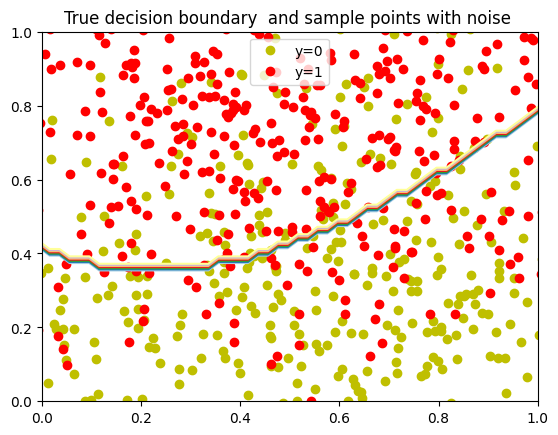

In [ ]:
# Create a dataset object
data_set = Data(noise_std=0.2) #try with 0, 0.2, 0.5
data_set.plot()

In [ ]:
# Get some validation data
torch.manual_seed(0)
validation_set = Data(train=False)

* Create a NN

In [ ]:
class Net(nn.Module):
    # Constructor
    def __init__(self, in_size, n_hidden, out_size, p=0):
        super(Net, self).__init__()
        self.drop = nn.Dropout(p=p)
        #self.drop1 = nn.Dropout(p=p)
        self.linear1 = nn.Linear(in_size, n_hidden)
        self.linear2 = nn.Linear(n_hidden, n_hidden)
        self.linear3 = nn.Linear(n_hidden, out_size)

    # Prediction function
    def forward(self, x):
        x = torch.relu(self.drop(self.linear1(x)))
        x = torch.relu(self.drop(self.linear2(x)))
        x = self.linear3(x)
        return x

In [ ]:
# Create two model objects: model without dropout and model with dropout
model = Net(2, 300, 2, p = 0)
model_drop = Net(2, 300, 2, p=0.5) # try with p = 0.2, 0.4, 0.8

In [ ]:
# Set the model to training mode
model_drop.train()

# Set optimizer functions and criterion functions
optimizer_ofit = torch.optim.Adam(model.parameters(), lr=0.01)
optimizer_drop = torch.optim.Adam(model_drop.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()

# Initialize the LOSS dictionary to store the loss
LOSS = {}
LOSS['training data no dropout'] = []
LOSS['validation data no dropout'] = []
LOSS['training data dropout'] = []
LOSS['validation data dropout'] = []


# Train the model
epochs = 500

def train_model(epochs):
    for epoch in range(epochs):
        #all the samples are used for training
        yhat = model(data_set.x)
        yhat_drop = model_drop(data_set.x)
        loss = criterion(yhat, data_set.y)
        loss_drop = criterion(yhat_drop, data_set.y)

        #store the loss for both the training and validation data for both models
        LOSS['training data no dropout'].append(loss.item())
        LOSS['validation data no dropout'].append(criterion(model(validation_set.x), validation_set.y).item())
        LOSS['training data dropout'].append(loss_drop.item())
        model_drop.eval()
        LOSS['validation data dropout'].append(criterion(model_drop(validation_set.x), validation_set.y).item())
        model_drop.train()

        optimizer_ofit.zero_grad()
        optimizer_drop.zero_grad()
        loss.backward()
        loss_drop.backward()
        optimizer_ofit.step()
        optimizer_drop.step()

train_model(epochs)

In [ ]:
# Set the model to evaluation model
model_drop.eval() ###### do keep in mind to tell model we are in eval phase both in case of dropout and normalization

# Print out the accuracy of the model without dropout
print("The accuracy of the model without dropout: ", accuracy(model, validation_set))

# Print out the accuracy of the model with dropout
print("The accuracy of the model with dropout: ", accuracy(model_drop, validation_set))

The accuracy of the model without dropout:  0.869
The accuracy of the model with dropout:  0.863


* Compare results from NN with dropout and without dropout

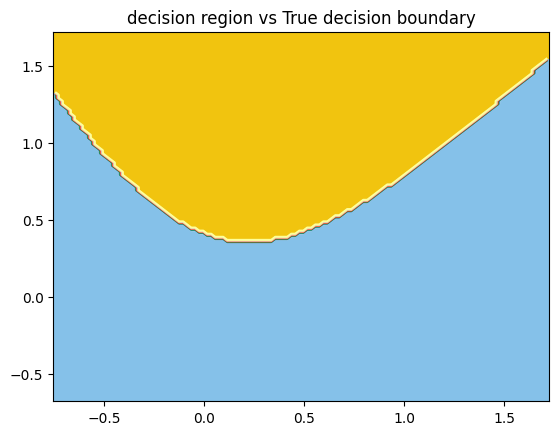

In [ ]:
# Plot the decision boundary and the prediction
plot_decision_regions_3class(data_set)

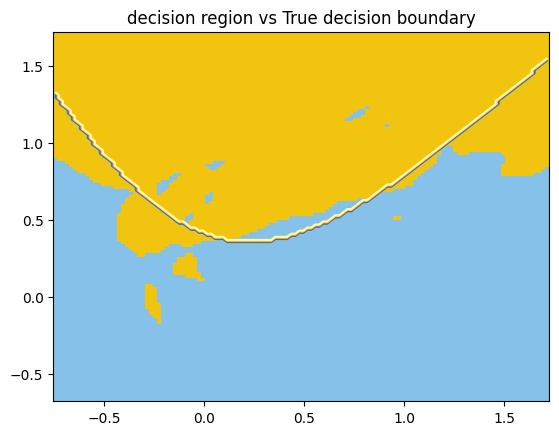

In [ ]:
# The model without dropout
plot_decision_regions_3class(data_set, model)

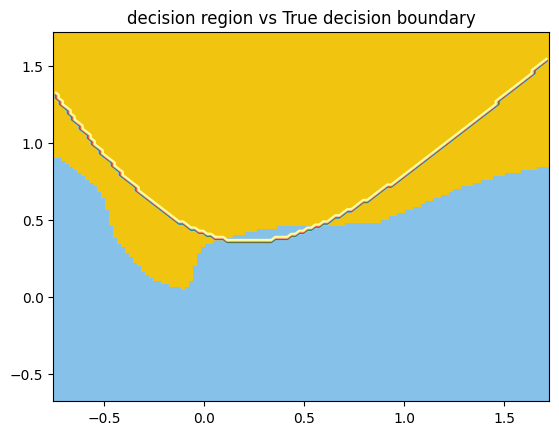

In [ ]:
# The model with dropout
plot_decision_regions_3class(data_set, model_drop)

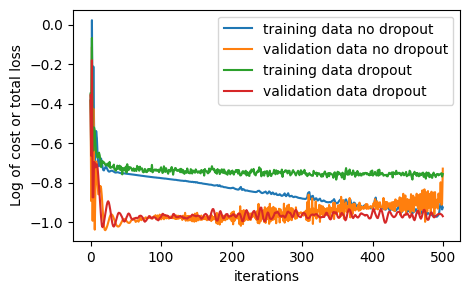

In [ ]:
# Plot the LOSS
plt.figure(figsize=(5,3))
def plot_LOSS():
    for key, value in LOSS.items():
        plt.plot(np.log(np.array(value)), label=key)
        plt.legend()
        plt.xlabel("iterations")
        plt.ylabel("Log of cost or total loss")

plot_LOSS()